# NLP con Disaster Tweets

---

### Panoramica del Progetto

Questo notebook implementa una **pipeline completa** per la competizione Kaggle
[Natural Language Processing with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started).
L'obiettivo è classificare tweet in due categorie: **disastro reale (1)** o **non disastro (0)**.

La pipeline si compone di **sei tecniche**:

|   | Tecnica | Descrizione |
|---|---------|-------------|
| 1 | **Caricamento dataset** | Caricamento dei tre dataset; pulizia del terzo dataset ed unione finale |
| 2 | **Analisi esplorativa dei dati (EDA)** | Distribuzione delle classi, lunghezza tweet, estrazione delle top 10 keywords (generali, disaster, no-disaster), estrazione di hastag, menzioni e location con mappa finale |
| 3 | **Tokenizzazione con Twitter-RoBERTa** | Configurazione del tokenizzatore `cardiffnlp/twitter-roberta-base` addestrato su milioni di tweet |
| 4 | **Configurazione delle metriche di valutazione** | Monitorare le performance del modello alla fine di ogni epochs |
| 5 | **Setup Training e Cross-Validation** | Implementata un'architettura più robusta basata sulla cross-validation |
| 6 | **Ensembling dei risultati e submission** | Raccolta delle predizioni per ogni fold per generare una singola submission altamente accurata |

---

### File Necessari

Assicurarsi di avere i seguenti file nella stessa cartella del notebook:

- `train.csv` — dataset di training ufficiale Kaggle (~7600 tweet)
- `test.csv` — dataset di test ufficiale Kaggle (~3200 tweet)
- `socialmedia-disaster-tweets-DFE.csv`

In [ ]:
!pip install -q transformers[torch] datasets evaluate contractions

# Section 1: Importazione ed integrazione dei dataset
---
Questa cella rappresenta la **fase di preparazione** dell'ambiente di lavoro e dei dati. Oltre a caricare i dati standard della competizione, viene effettuata una *Data Augmentation* integrando un dataset esterno per migliorare le performance del modello.
Le operazioni eseguite sono:
*   **Importazione librerie:** strumenti standard per la manipolazione dei dati (`numpy`, `pandas`), `re` per le regex, `html` per il parsing, `contractions`per espandere le contrazioni inglesi, `torch` e i moduli principali della libreria `transformers` di **Hugging Face** per il caricamento/tokenizzazione/addestramento dei modelli LLM, `datasets` ed `evaluate` per la gestione dei dati testuali e il calcolo delle metriche, `StratifiedKFold` da `sklearn` per la cross validation
*   **Caricamento dei dati:** `train.csv`, `test.csv` e `socialmedia-disaster-tweets-DFE.csv` noto per contenere tweet simili a quelli del task principale con lo scopo di aumentare la quantità di dati a disposizione per l'addestramento
*   **Pulizia ed allineamento del dataset esterno:** affinchè il dataset esterno sia compatibile con i dati di training originali sono state rimosse *ambiguità*, è stato effettuato il *mapping dei target* ed eliminate righe con valori nulli
*  **Unione e rimozione dei duplicati:** uniamo il dataset originale di training con quello appena ripulito tramite `pd.concat`
*  **Verifica finale:** viene stampato il numero totale di tweet nel dataset unito per avere un riscontro immediato della grandezza del nostro nuovo corpus di addestramento





In [ ]:
import pandas as pd
import numpy as np
import re, html, torch, gc, contractions
from sklearn.model_selection import StratifiedKFold
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset
import evaluate

# Caricamento dataset
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
disaster_df = pd.read_csv("socialmedia-disaster-tweets-DFE.csv")

# Pulizia e Mapping terzo dataset
disaster_df = disaster_df[disaster_df['choose_one'] != "Can't Decide"].copy()
disaster_df['target'] = disaster_df['choose_one'].map({'Relevant': 1, 'Not Relevant': 0})
disaster_df = disaster_df[['text', 'target']].dropna()

# Unione e rimozione duplicati
train_combined = pd.concat([train_df[['text', 'target']], disaster_df], axis=0)
train_combined = train_combined.drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"Dataset unito: {train_combined.shape[0]} tweet")

Dataset unito: 11267 tweet


# Section 2: Analisi esplorativa dei dati (EDA)
## Parte 1: distribuzioni e metadati
---
Questa cella è dedicata alla prima fase della **Exploratory Data Analysis (EDA)**.
L'obiettivo è comprendere a fondo la natura del dataset attraverso visualizzazioni grafiche, analizzando il bilanciamento delle classi, le caratteristiche testuali e l'incidenza di specifici metadati (*keyword, hastag e menzioni*)
## Distribuzione delle classi
*  Utilizziamo `sns.countplot` per visualizzare il numero di tweet appartenenti alla classe `0` (*non disastro*) e alla classe `1` (*disastro*)
*  Si tratta del **primo passo fondamentale** in un task di classificazione. Capire se il dataset è bilanciato o sbilanciato aiuterà a scegliere le metriche di valutazione più appropriate e a decidere se applicare future tecniche di bilanciamento
## Analisi della lunghezza dei tweet (text_len)
*  La lunghezza in caratteri di ogni tweet viene calcolata applicando la funzione `len` alla colonna `text`, salvando il risultato in una nuova colonna
* Succesivamente, si vanno a sovrappore due istogrammi (*uno per classe*) calcolando anche la stima della densità del *kernel* (`kde = True`) per ottenere curve smussate
* In questo modo si può scoprire se c'è una correlazione tra la lunghezza del testo e la natura del tweet

> Ad esempio, i tweet di emergenza reali potrebbero essere mediamenti più brevi e concisi oppure più lunghi per fornire dettagli cruciali

## **Analisi delle keyword frequenti**
* Vengono creati *tre barplot* affiancati: il **primo** mostra le 10 keyword più frequenti in assoluto, il **secondo e il terzo** filtrano il dataset per mostrare le keyword dominanti rispettivamente per i **tweet sui disastri** (**target = 1**) e per i **tweet generici** (**target = 0**)
* Vengono indicati, dunque, termini specifici che hanno un forte potere predittivo. Se una keyword appare spesso nella *classe 1* ma quasi mai nella *classe 0*, il modello vi presterà **molta** attenzione

## **Estrazione ed esplorazione di hashtag, menzioni e location**
* **Regex:** viene definita una funzione `extract_patterns` e si utilizza `re.findall` per estrarre **tutti gli hastag** e **le menzioni.** Si convertono gli hastag in minuscolo per raggruppare versioni scritte in modo diverso (ad esempio, #Fire e #fire)
* Viene usata la classe `Counter` per contare le occorrenze di ogni hastag e menzione
* Vengono tracciati tre barplot: **top 10 hastag, top 10 menzioni, top 10 location dichiarate**
* Su Twitter, hastag e menzioni racchiudono un alto contenuto semantico. Gli hastag spesso categorizzano l'evento (ad esempio, #earthquake) mentre le menzioni potrebbero indicare agenzie di soccorso o notiziari. Le location possono evidenziare hotspot geografici nel dataset anche se spesso si tratta di *dati rumorosi* o inseriti manualmente dagli utenti

/tmp/ipykernel_2087/864391239.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




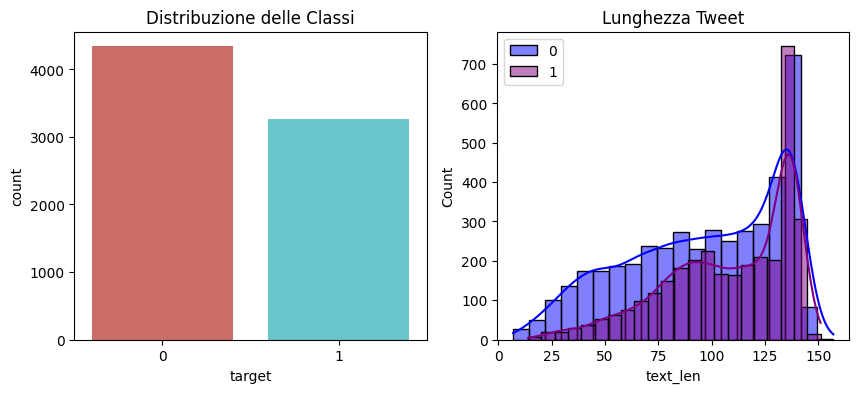

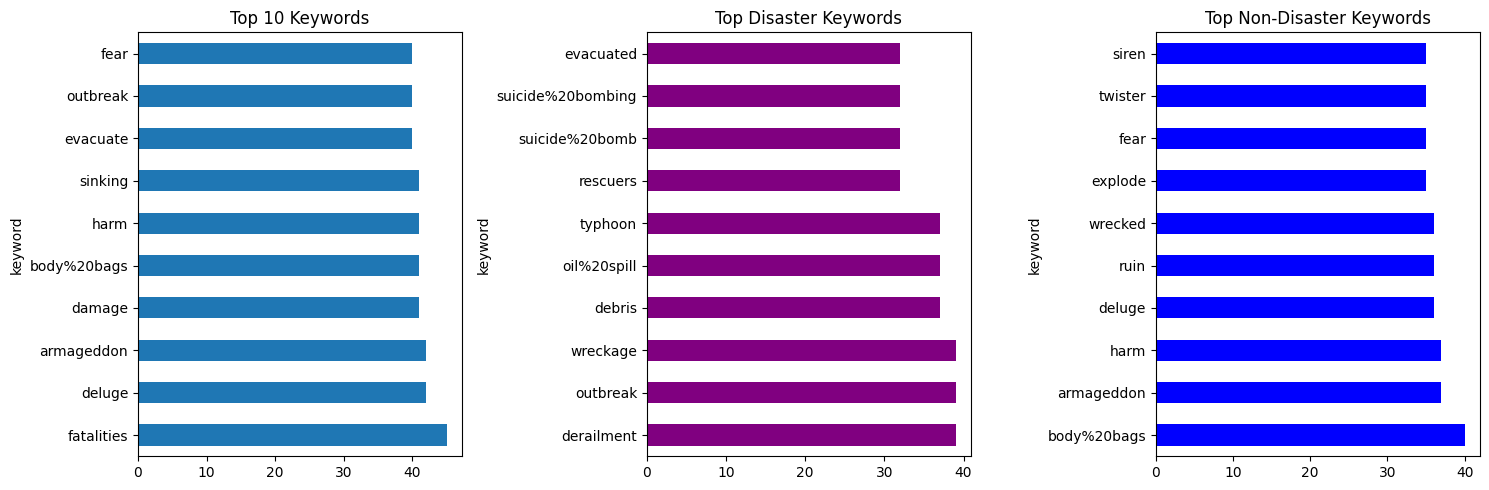

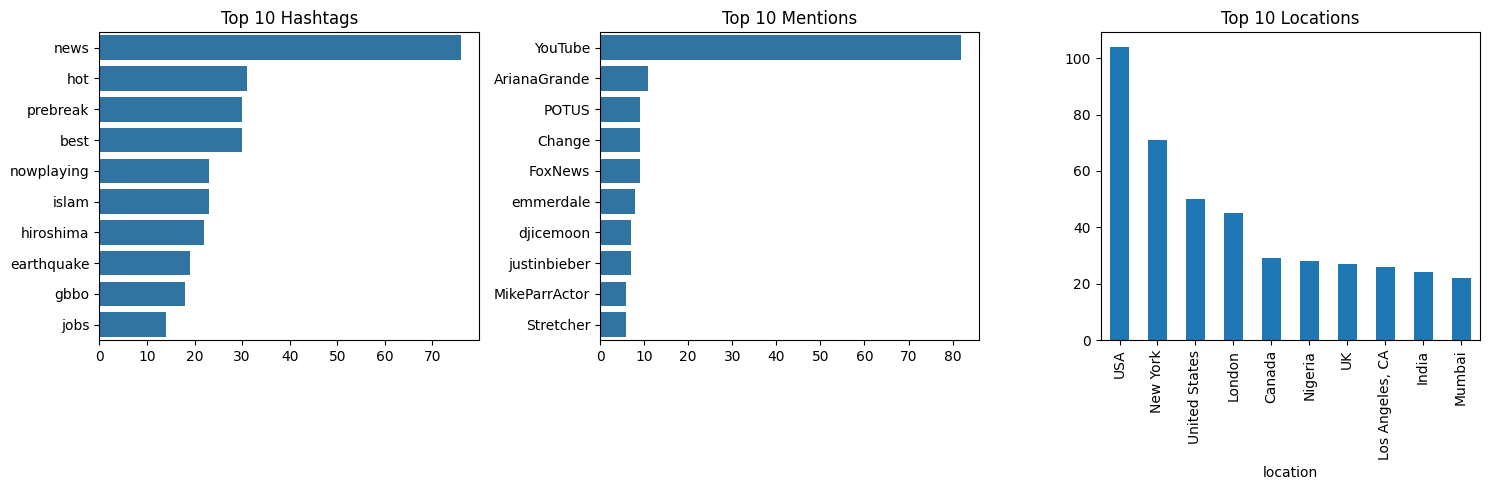

In [ ]:
# Distribuzione Classi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=train_df, palette='hls')
plt.title('Distribuzione delle Classi')

# Lunghezza Tweet
train_df['text_len'] = train_df['text'].apply(len)
plt.subplot(1, 2, 2)
sns.histplot(train_df[train_df['target']==0]['text_len'], label='0', kde=True, color='blue')
sns.histplot(train_df[train_df['target']==1]['text_len'], label='1', kde=True, color='purple')
plt.title('Lunghezza Tweet')
plt.legend()
plt.show()

# Top Keywords (Generali, Disaster, Non-Disaster)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
train_df['keyword'].value_counts().head(10).plot(kind='barh', title='Top 10 Keywords')
plt.subplot(1, 3, 2)
train_df[train_df['target']==1]['keyword'].value_counts().head(10).plot(kind='barh', title='Top Disaster Keywords', color='purple')
plt.subplot(1, 3, 3)
train_df[train_df['target']==0]['keyword'].value_counts().head(10).plot(kind='barh', title='Top Non-Disaster Keywords', color='blue')
plt.tight_layout()
plt.show()

# 4. Hashtag, Menzioni, Location
def extract_patterns(text, pattern): return re.findall(pattern, text)
all_hashtags = [tag.lower() for tags in train_df['text'].apply(lambda x: extract_patterns(x, r'#(\w+)')) for tag in tags]
all_mentions = [men for mens in train_df['text'].apply(lambda x: extract_patterns(x, r'@(\w+)')) for men in mens]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); sns.barplot(x=[x[1] for x in Counter(all_hashtags).most_common(10)], y=[x[0] for x in Counter(all_hashtags).most_common(10)]).set_title('Top 10 Hashtags')
plt.subplot(1, 3, 2); sns.barplot(x=[x[1] for x in Counter(all_mentions).most_common(10)], y=[x[0] for x in Counter(all_mentions).most_common(10)]).set_title('Top 10 Mentions')
plt.subplot(1, 3, 3); train_df['location'].value_counts().head(10).plot(kind='bar', title='Top 10 Locations')
plt.tight_layout(); plt.show()

## Parte 2: distribuzione geografica interattiva
---
Questa cella espande l'analisi esplorativa dei dati introducendo la libreria `Plotly`, uno strumento potente per creare grafici dinamici ed interattivi.
L'obiettivo qui è **mappare** visivamente la provenzienza dei tweet per capire se esistono dei pattern geografici legati al dataset.
## Importazioni
* `import plotly.express as px`
## Preparazione dei dati geografici (location_df)
* Vengono usati i conteggi delle località con `value_counts()`
* `reset_index()` viene utilizzata per convertire il risultato in un *Dataframe*
* Vengono rinominate le colonne in `['location_name', 'count']` per avere un riferimento chiaro e leggibile nei passaggi successivi
## Filtraggio (top 100)
* Si selezionano solamente le **100 location più frequenti**
* I dati testuali sulle località nei tweet sono spesso molto rumorosi (*worldwide* o *in my bed*). Renderizzare migliaia di punti irrilevanti appesantirebbe la mappa e renderebbe il grafico illegibile
## Creazioe della mappa
* `locationmode = 'country names'` specifica come Plotly deve interpretare le stringhe. In questo caso, cercherà di far corrispondere i testi ai nomi degli Stati.
> Se ne dataset abbondano nomi di città, Plotly farà una stima ma il match migliore si ha con le nazioni


* `size = 'count'`: più alto è il numero di tweet per una località, più grande sarà il cerchio sulla mappa
* `hover_name = 'location_name'`: permette l'apparizione del tooltip con il nome della location quando si passa col mouse sul cerchio



In [ ]:
import plotly.express as px

# Implementazione scattergeo per la location
location_df = train_df['location'].value_counts().reset_index()
location_df.columns = ['location_name', 'count']

# Top 50/100 location
top_locations = location_df.head(100)

fig = px.scatter_geo(top_locations,
                     locations="location_name",
                     locationmode='country names', # Riconosce nomi come "USA", "Canada", "Italy"
                     size="count",                 # La grandezza del punto dipende dal numero di tweet
                     hover_name="location_name",    # Mostra il nome al passaggio del mouse
                     projection="natural earth",
                     title='Distribuzione Geografica dei Tweet (Top 100 Location)',
                     color="count",
                     color_continuous_scale=px.colors.sequential.Plasma)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

# Section 3: Pre-processing avanzato del testo
## Text cleaning
---
Questa cella rappresenta **il cuore** della preparazione dei dati testuali per il NLP. Poichè i tweet sono intrinsecamente *sporchi* (slang, link, emoji e formattazioni errate), viene definita una **pipeline** di pulizia personalizzata `clean_text_advanced`per standardizzare il testo e ridurre il rumore prima di passarlo al modello
* `html.unescape(text)`: i dati estratti dal web spesso presentano **entità HTML** che vengono riconvertiti nei loro caratteri originali (*esempio: &amp in &)
* `contractions.fix(text)`: la lingua inglese fa largo uso di contrazioni. Utilizzando la libreria `contractions` ne viene estesa la forma. Il modello, in questo modo, viene aiutato nell'uniformare la semantica (*esempio: don't e do not verranno riconosciuti come la stessa struttura logica*)
* `text.lower()`: il testo viene convertito in minuscolo cosi da ridurre la dimensione del vocabolario del modello (*Fire, FIRE, fire diventeranno un unico token*), facendo concentrare il modello sul significato della parola piuttosto che sulla formattazione
* `re.sub(r"@\w+","", text)`: rimuove le menzioni ad altri utenti
* `re.sub(r"\bRT\b","",text)`: elimina la sigla **RT** (*retweet*)
* `text.encode("ascii", "ignore").decode("utf-8)`: rimuove emojii, carattere speciali e simboli strani
* `re.sub(r"[^a-zA-Z\s]","",text)`: rimuove la punteggiatura residua e i numeri, mantenendo esclusivamente le lettere dell'alfabeto e gli spazi
* `re.sub(r"\s+","",text)`: tutte le rimozioni precedenti lasciano spesso fastidiosi spazi vuoti e multipli. Questa riga li condensa tutti in un singolo spazio e rimuove gli spazi iniziali e finali della stringa
* `.apply`: applica questa funzione a ogni singola riga della colonna `text`
> La stessa funzione viene applicata sia al `train_combined` ovvero il dataset di addestramento sia a quello di test. I dati di test devono subire le esatte trasformazioni usate in fase di training, altrimenti il modello si troverebbe di fronte a un input con caratteristiche sconosciute




In [ ]:
def clean_text_advanced(text):
    text = html.unescape(text) # Converte &amp; in &
    text = contractions.fix(text) # Espande don't in do not
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text) # Rimuove URL
    text = re.sub(r"@\w+", "", text) # Rimuove Menzioni
    text = re.sub(r"\bRT\b", "", text) # Rimuove sigla Retweet
    text = text.encode("ascii", "ignore").decode("utf-8") # Rimuove Emoji
    text = re.sub(r"[^a-zA-Z\s]", "", text) # Rimuove punteggiatura residua
    text = re.sub(r"\s+", " ", text).strip() # Normalizza spazi
    return text

train_combined['text'] = train_combined['text'].apply(clean_text_advanced)
test_df['text'] = test_df['text'].apply(clean_text_advanced)

# Section 4: Preparazione del modello, tokenizzazione e metriche di valutazione
---
Questa cella segna **il passaggio dall'elaborazione dei dati puri al setup dell'architettura Deep Learning.**
## Inizializzazione toker e metrica
* `AutoTokenizer.from_pretrained(...)`: carica il tokenizer associato al modello. Il tokenizer è il vocabolario che mappa le parole in ID numerici
* `evaluate.load("f1")`: viene caricata la metrica **F1-score**. Quest'ultima è molto più affidabile della semplice *accuracy* in quanto bilancia *Precision* e *Recall*
## Funzione di tokenizzazione (tokenize_fn)
La funzione di **padding** e di **truncation** permettono di tagliare i tweet troppo lunghi ed aggiungono zeri a quelli troppo corti per uniformarli. Poichè i tweet sono intrisecamente brevi, impostare la lunghezza massima dei token a 128 accelera drasticamente i tempi di addestramento e riduce il consumo di memoria della GPu senza la perdita delle informazioni
## Calcolo metriche (compute_metrics)
Funzione che viene chiamata dal `Trainer` alla fine di ogni epochs per valutare come sta imparando il modello.
* `logits, labels = eval_pred`: estrae le previsioni grezze del modello e le etichette reali
* `np.argmax(logits, axis = 1) :| logits`: sono probabilità continue per entrambe le classi. Questa funzione estrae l'indice della classe con la probabilità più alta (trasformando l'output in un netto 0 o 1)
* `average = "macro"`: calcola l'**F1-Score** separatamente per la classe disastro e non disastro, ne fa poi una media non pesata. Tratta entrambe le classi con la stessa importanza, penalizzando il modello se impara a riconoscere bene solo la classe maggioritaria
## Tokenizzazione del test set
Applicando la funzione `.map(tokenize_fn, batched = True)` possiamo elaborare i dati a blocchi anzichè uno per volta, velocizzando enormemente il processo grazie al parallelismo. Viene fatto *una volta sola* sul test set per tenerlo pronto per la fase di inferenza finale

# `cardiffnlp/twitter-roberta-base`
---
|   | Tecnica | Descrizione |
|---|---------|-------------|
| 1 | **BERT (Google)** | E' l'architettura che legge il testo in modo bidirezionale (*guarda sia le parole precedenti che quelle successive per capire il contesto*) |
| 2 | **RoBERTa** | E' una versione ottimizzata di BERT (*sia per Robustly optimized BERT approach*) |
| 3 | **Modello di CardiffNLP** | L' Università di Cardiff ha preso l'architettura RoBERTa e l'ha addestrata su circa **58 milioni di tweet**|
---
* **Domain adaptation:** i modelli classici sono abituati a testi formali e grammaticalmente perfetti. Se si da a BERT un tweet pieno di slang, abbreviazioni, errori grammaticali o sintassi spezzata, farà molta fatica
* **Capisce l'intento nei testi brevi:** i tweet sono limitati in caratteri, il che significa che il contesto è iper-condensato. L'architettura RoBERTa eccelle proprio nell'estrarre relazioni complesse tra le parole in sequenze brevi, aiutando il modello a capire, ad esempio, se la parola "fuoco" in un tweet di 10 parole si riferisce a un incensio reale o all'uscita di una canzone (*this track is fire*)


In [ ]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
f1_metric = evaluate.load("f1")

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"f1": f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]}

# Tokenizziamo il test set una volta sola
test_ds = Dataset.from_pandas(test_df[['text']]).map(tokenize_fn, batched=True)

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

# Section 5: Stratified K-Fold, early stopping ed ensembling
---
Invece di addestrare un singolo modello su tutto il dataset, si va ad implementare una validazione incrociata robusta (**Stratified K-Fold**) unita ad una tecnica di **Ensembling**.
Si addestrano, dunque, **5 modelli separati,** ognuno su una porzione diversa di dati per poi raccogliere le previsioni di ciascuno e farne la media alla fine.
* **Stratified K-Fold (n_splits = 5):** il dataset viene diviso in 5 fold. Per 5 volte, il modello si allenerà su 4 parti e si valuterà sulla quinta. L'utilizzo di `Stratified` garantisce che la porzione tra tweet disastrosi e non disastrosi rimanga identica in ogni singolo fold, evitando di addestrare un modello su un set di dati sbilanciato per puro caso
* **Fold loop:** vengono creati i dataset di training e validazione per il fold corrente. Si rinomina la colonna `target` in `label` per permettere al modello di calcolare la *loss*. Il modello pre-addestrato viene ricaricato all'interno del ciclo. Questo **è vitale**: ogni fold deve partire da un modello vergine. Se venisse caricato fuori dal ciclo, il secondo fold continuerebbe l'addestramento sui dati del primo fold, creando un **gravissimo data leakage**
* **Configurazione iperparametri (TrainingArguments):** `lr_scheduler_type = "cosine"`, `warmup_ratio = 0.1`permettono di non mantenere un *learning rate fisso* ma lo fanno crescere gradualmente nel primo 10% dell'addestramento in modo tale da evitare shock iniziali ai pesi del modello. Successivamente, il learning rate decresce seguendo una curva del *coseno.* Questo aiuta il modello a settarsi con precisione nel minimo globale della funzione di perdita
* **Ottimizzazione su F1:** `load_best_model_at_end = True` e `metric_for_best_model = "f1"` permettono al Trainer di salvare i checkpoint alla fine di ogni epoch e, al termine del fold, di ricaricare i pesi dell'epoch che ha ottenuto il punteggio F1 più alto, scartando tutte le successive in cui il modello potrebbe aver overfittato
* **Trainer ed Early stopping:** con `EarlyStoppingCallback(early_stopping_patience = 2)` se il punteggio F1 sul set di validazione non migliora per 2 epochs consecutive, il Trainer interrompe l'addestramento in anticipo. Previene l'eccessivo adattamento ai dati di training
* **Ensembling:** al termine di ogni fold, il modello appena addestrato viene utilizzato per generare previsioni grezze (*logits*) sul test set ufficiale. Alla fine dei 5 fold, si fa la media di queste probabilità
* **Gestione VRAM:** alla fine di ogni fold distruggiamo gli oggetti Python, svuotiamo la cache della GPU e si forza la raccolta dei rifiuti in RAM
> Senza questi passaggi, il notebook andrebbe quasi certamente in errore OUT OF MEMORY al secondo o terzo fold

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_test_preds = []

for fold, (t_idx, v_idx) in enumerate(skf.split(train_combined, train_combined['target'])):
    print(f"\n INIZIO FOLD {fold + 1}")

    # Split dati
    ds_train = Dataset.from_pandas(train_combined.iloc[t_idx].rename(columns={'target':'label'})).map(tokenize_fn, batched=True)
    ds_val = Dataset.from_pandas(train_combined.iloc[v_idx].rename(columns={'target':'label'})).map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    # Configurazione TrainingArguments
    args = TrainingArguments(
        output_dir=f"./results_fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        weight_decay=0.01,
        num_train_epochs=5,
        lr_scheduler_type="cosine",       # Scheduler a coseno
        warmup_ratio=0.1,                 # Warmup al 10%
        load_best_model_at_end=True,
        metric_for_best_model="f1",       # Ottimizza su F1
        fp16=True,                        # Velocizza su GPU
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        compute_metrics=compute_metrics,
        # Early Stopping
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # Predizioni Logits per Averaging finale
    fold_logits = trainer.predict(test_ds).predictions
    all_test_preds.append(fold_logits)

    # Pulizia memoria GPU
    del model, trainer
    torch.cuda.empty_cache()
    gc.collect()


--- INIZIO FOLD 1 ---


Map:   0%|          | 0/9013 [00:00<?, ? examples/s]

Map:   0%|          | 0/2254 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ra

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

# Section 6: generazione della Submission finale tramite Ensembling
---
Questa è la cella conclusiva del progetto.
Qui vengono raccolti i risultati dell'addestramento effettuato per generare le previsioni definitive e preparare il file da inviare alla competizione
* **Soft voting ensembling:** `np.mean(all_test_preds, axis = 0)` calcola la media matematica dei 5 valori precedenti per ogni tweet. Questa tecnica invece di far semplicemente votare i modelli sulla classe finale (*ad esempio: 3 modelli dicono disastro, 2 dicono non disastro*), fa la media delle loro *incertezze.* Se un modello è sicuro al 99% e un altro solo al 51%, la media rifletterà questa sfumatura, garantendo una previsione finale molto più robusta e resistente agli errori di un singolo mdoello
* **Estrazione etichette finali:** una volta ottenuta la media dei logits, si convertono le probabilità continue nelle etichette discrete (0 o 1). Viene scelto l'indice della colonna che ha il valore medio più alto
## Creazione del dataframe Submission
* `id`: ID originali direttamente dal test set per mappare correttamente le previsioni ai tweet originali
* `target`: viene inserito l'array `final_labels`

In [ ]:
# Media dei risultati di tutti i fold
final_logits = np.mean(all_test_preds, axis=0)
final_labels = np.argmax(final_logits, axis=-1)

# Generazione file CSV
submission = pd.DataFrame({'id': test_df['id'], 'target': final_labels})
submission.to_csv('submission_roberta_v3.csv', index=False)

print("Processo completato! Il file 'submission_roberta_v3.csv' è pronto")
print("Score finale: 0.91418")

Processo completato! Il file 'submission.csv' è pronto per Kaggle.
